In [434]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from neural_net import NeuralNet
import mushrooms as shroom
import graphics
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [435]:
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target
X = np.array(X)

In [436]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y)

In [ ]:
y = np.astype(y, int)
y_processed = np.zeros((len(y), 10))
for i, y_p in enumerate(y_processed):
    y_p[y[i]] =1

y = y_processed 
X = X/255
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [438]:
X.shape

(70000, 784)

In [ ]:
neural_net = NeuralNet((28**2, 256, 10), learning_rate=0.03, random_state=42)
neural_net.layers[0].activation_method="ReLu"
neural_net.layers[-1].activation_method="softmax"
epochs = 10
losses, y_pred = neural_net.train(X_train[0:4000], y_train[0:4000], epochs, 64)

print("prev-times for backprop: 9.683, 9.509, 9.978")

EPOCH: 1    LOSS: 1.4571365453000438    Delta: 0
Timer backprop: 0.3453
Timer backprop1: 0.2362
Timer batch: 0.4697
Timer epoch: 0.487
EPOCH: 2    LOSS: 0.8817141631588717    Delta: -0.5754
Timer backprop: 0.3428
Timer backprop1: 0.234
Timer batch: 0.456
Timer epoch: 0.4699
EPOCH: 3    LOSS: 0.7523526195365343    Delta: -0.1294
Timer backprop: 0.3424
Timer backprop1: 0.2353
Timer batch: 0.455
Timer epoch: 0.4678
EPOCH: 4    LOSS: 0.6673369046568457    Delta: -0.08502
Timer backprop: 0.3289
Timer backprop1: 0.2294
Timer batch: 0.4317
Timer epoch: 0.4449
EPOCH: 5    LOSS: 0.6369877930269394    Delta: -0.03035
Timer backprop: 0.3569
Timer backprop1: 0.2469
Timer batch: 0.4653
Timer epoch: 0.479
EPOCH: 6    LOSS: 0.598195698387368    Delta: -0.03879
Timer backprop: 0.3394
Timer backprop1: 0.229
Timer batch: 0.439
Timer epoch: 0.4516
EPOCH: 7    LOSS: 0.5678277134706505    Delta: -0.03037
Timer backprop: 0.3513
Timer backprop1: 0.2448
Timer batch: 0.4597
Timer epoch: 0.473
EPOCH: 8    LOSS:

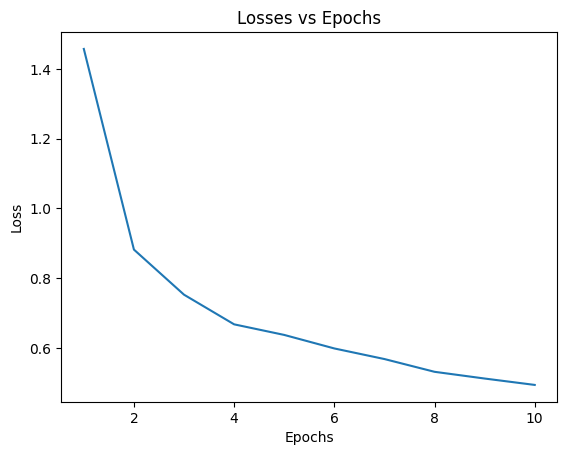

In [ ]:
graphics.plot_losses(epochs, losses)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = neural_net.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1, 0)
print(f"Accuracy: {accuracy_score(y_pred, y_test)}")

def display_num(ax, X, i, true, pred):
    X_image = np.swapaxes(np.array(np.split(X, 28, axis=1)), 1, 0)
    ax.imshow(X_image[i], cmap="gray_r")
    ax.set_title(f'True: {true} Predicted: {pred}', c="blue" if true == pred else "red")
    ax.axis('off') # Hide axis ticks

rows = 6
cols = 4

fig, axs = plt.subplots(rows, cols, figsize=(10, 6))

for i in range(24):
    current_row = i // cols
    current_col = i % cols
    
    # Select the correct subplot axis
    ax = axs[current_row, current_col]
    display_num(ax, X_test, i+50, y_test.argmax(axis=1)[i+50], y_pred.argmax(axis=1)[i+50])
    print(f"Prediction: {y_pred.argmax(axis=1)[i]}")

KeyboardInterrupt: 